In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Supervised Contrastive Loss for Rare PDR Lesions (UWF Modality)

> **💡 KAGGLE SETUP NOTE:** Ensure you have toggled **"Internet" to ON** in your Kaggle Notebook settings (right-side panel) so the ResNet50 backbone can download its pre-trained ImageNet weights!

## 🩺 Clinical Motivation: Focusing on Rare Lesions
Proliferative Diabetic Retinopathy (PDR) involves rare but highly dangerous lesions, notably **Neovascularization (NV)**, **Vitreous Hemorrhage (VH)**, and **Retinal Detachment (RD)**. Because these lesions are scarce in the dataset but critical for diagnosis, standard loss functions often overlook them, leading to severe False Negatives.

To tackle this, we apply **Supervised Contrastive Loss (SupCon)** directly on the model's intermediate features. The core idea is to:
1. **Pull together** embeddings of images that contain these rare lesions.
2. **Push apart** embeddings of images that do not.

By doing this at both the **early feature branch** (layer 2) and **deep feature branch** (layer 4) of our ResNet50 architecture, we force the network to explicitly recognize and group the subtle patterns of these severe lesions before they are lost in the final classification layers.

## 🧮 Mathematical Formulation (Supervised Contrastive Loss)

Given a batch of embeddings $z_i$ and their labels (whether they contain rare lesions or not), the Supervised Contrastive Loss for the $i$-th sample is:

$$ L_{sup,i} = \frac{-1}{|P(i)|} \sum_{p \in P(i)} \log \frac{\exp(z_i \cdot z_p / \tau)}{\sum_{a \in A(i)} \exp(z_i \cdot z_a / \tau)} $$

Where:
- $z_i$ is the projected feature embedding.
- $P(i)$ is the set of positive examples (images belonging to the same "rare lesion" class as $i$).
- $A(i)$ is the set of all other examples in the batch.
- $\tau$ is the temperature hyperparameter.

We calculate this loss for both early and deep features and add it to our standard BCE/CrossEntropy classification losses.

In [2]:
# 1. IMPORTS & SETUP
import os
import cv2
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore') # Ignore undefined metric warnings early in training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# KAGGLE-READY PATHS
KAGGLE_DIR = '/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR'
LOCAL_DIR = '../MMRDR'
DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else LOCAL_DIR
print(f"Dataset Directory Set To: {DATA_DIR}")

Using device: cuda
Dataset Directory Set To: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR


## 💾 Kaggle-Ready Checkpointing (12-Hour Session Limit)
Kaggle kernels time out after 12 hours. We need to save the model, optimizer, epoch, and best loss state so we can pick up right where we left off if the kernel restarts.

In [3]:
# 2. CHECKPOINTING SYSTEM
def save_checkpoint(state, is_best, filename='checkpoint.pth', best_filename='best_model.pth'):
    """Saves checkpoint to disk (Output directory in Kaggle: /kaggle/working/)"""
    torch.save(state, filename)
    if is_best:
        torch.save(state, best_filename)
        print(f"[*] Saved new best model to {best_filename}")

def load_checkpoint(checkpoint_path, model, optimizer, scheduler=None):
    """Loads state dicts and epoch into model and optimizer"""
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        if scheduler and 'scheduler' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler'])
        start_epoch = checkpoint['epoch']
        best_loss = checkpoint['best_loss']
        print(f"[*] Loaded checkpoint '{checkpoint_path}' (epoch {start_epoch})")
        return start_epoch, best_loss
    else:
        print(f"[!] No checkpoint found at '{checkpoint_path}', starting from scratch.")
        return 0, float('inf')

## 👁️ Pre-processing: UWF Elliptical Masking & Visualizations
Ultra-Widefield (UWF) images capture 200 degrees of the retina but often include artifacts like eyelashes and severe vignetting at the borders. We apply an elliptical mask to clean the images.

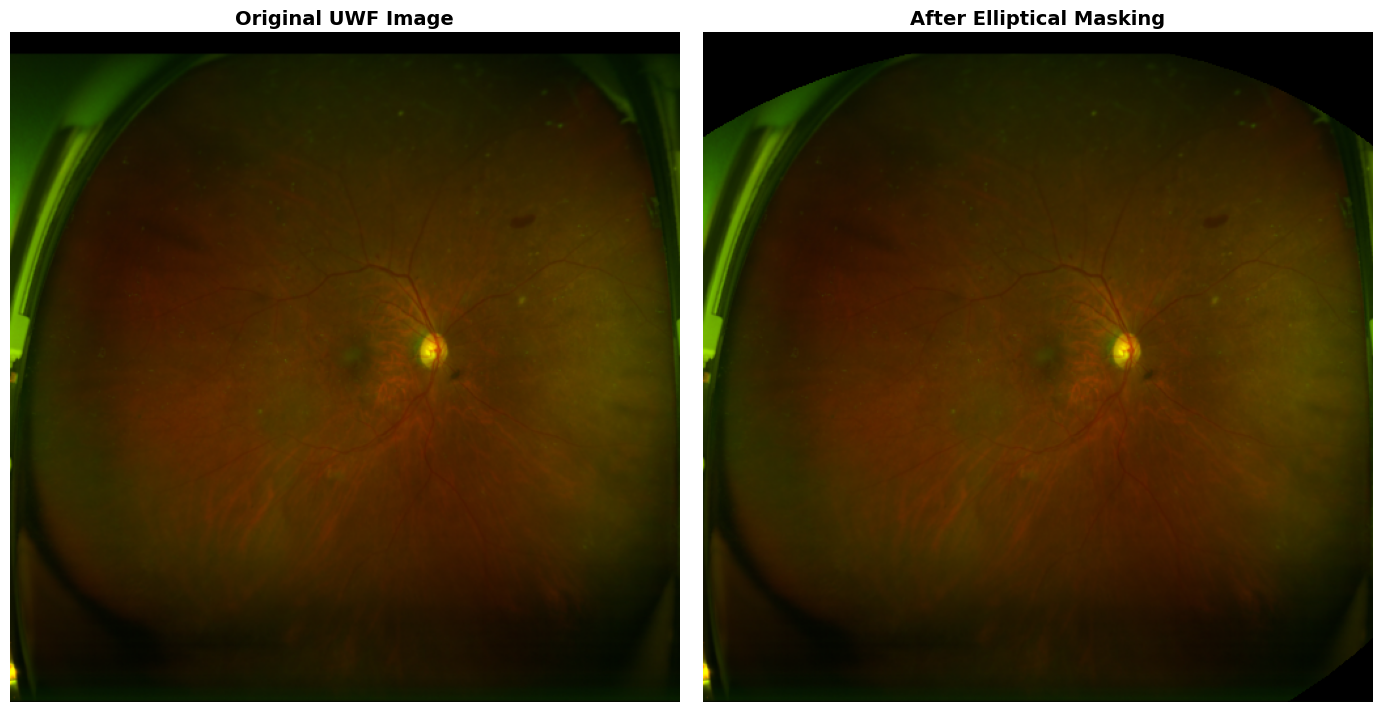

In [4]:
# 3. PRE-PROCESSING & MASKING
def apply_uwf_mask(pil_img, tightness=0.98):
    """Applies an elliptical mask tailored for UWF images to remove eyelid and eyelash artifacts."""
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return pil_img
    largest_contour = max(contours, key=cv2.contourArea)
    
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        scaled_ellipse = (ellipse[0], (ellipse[1][0]*tightness, ellipse[1][1]*tightness), ellipse[2])
        mask = np.zeros_like(gray)
        cv2.ellipse(mask, scaled_ellipse, 255, -1)
        clean_img = cv2.bitwise_and(img, img, mask=mask)
        return Image.fromarray(clean_img)
    return pil_img

def visualize_masking(image_path):
    if not os.path.exists(image_path):
        print(f"[!] Image {image_path} not found.")
        return
        
    original_img = Image.open(image_path).convert('RGB')
    original_img = original_img.resize((512, 512), Image.Resampling.BILINEAR)
    masked_img = apply_uwf_mask(original_img)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original_img)
    axes[0].set_title('Original UWF Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(masked_img)
    axes[1].set_title('After Elliptical Masking', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# Automatically fetch a real image from the dataset for visualization
import glob
img_list = glob.glob(os.path.join(DATA_DIR, 'MMRDR-UWF', 'img', '*.jpg'))
if img_list:
    visualize_masking(img_list[0])


### Dataset & DataLoaders
**Anti-Overfitting Fix:** We use Data Augmentation (Flips, Color Jitter, Rotation) to prevent memorization.

In [5]:
class UWF_Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        
        if not os.path.exists(img_path):
            image = Image.new('RGB', (512, 512), (0, 0, 0))
        else:
            image = Image.open(img_path).convert('RGB')
            image = image.resize((512, 512), Image.Resampling.BILINEAR)
            
        image = apply_uwf_mask(image)
        if self.transform: 
            image = self.transform(image)
            
        grade = int(row['grade'])
        lesion_str = str(row['lesion']).strip().strip('[]')
        lesions = np.array([float(x.strip()) for x in lesion_str.split(',') if x.strip()], dtype=np.float32)
        if len(lesions) != 7: lesions = np.zeros(7, dtype=np.float32)
        lesions = (lesions > 0).astype(np.float32)
        
        # SupCon Target: Does it have a rare lesion? (Indices 4: NV, 5: VH, 6: RD)
        has_rare_lesion = 1 if np.sum(lesions[4:]) > 0 else 0
            
        return image, grade, torch.tensor(lesions), torch.tensor(has_rare_lesion, dtype=torch.float32)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

csv_path = os.path.join(DATA_DIR, 'MMRDR-UWF', 'UWF.csv')
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    
    img_dir = os.path.join(DATA_DIR, 'MMRDR-UWF')
    
    train_loader = DataLoader(UWF_Dataset(train_df, img_dir, train_transform), batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(UWF_Dataset(val_df, img_dir, val_transform), batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
    print(f"DataLoaders initialized! Train: {len(train_df)}, Val: {len(val_df)}")
else:
    print("Dataset CSV not found. Ensure DATA_DIR is correct.")

DataLoaders initialized! Train: 8323, Val: 2081


## 🧠 Architecture: ResNet50 with SupCon Feature Branches

In [6]:
class UWF_SupConDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Load standard ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2 # Early feature (512 dims)
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4 # Deep feature (2048 dims)
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Projection heads for SupCon Loss
        self.proj_early = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        self.proj_deep = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )
        
        # FPN for Classification
        self.lat_l4 = nn.Conv2d(2048, 512, kernel_size=1)
        self.lat_l3 = nn.Conv2d(1024, 512, kernel_size=1)
        self.lat_l2 = nn.Conv2d(512, 512, kernel_size=1)
        self.lat_l1 = nn.Conv2d(256, 512, kernel_size=1)
        
        self.classifier_lesions = nn.Linear(512, 7)
        self.classifier_grade = nn.Linear(512, 5)

    def forward(self, x):
        x = self.stem(x)
        
        l1 = self.layer1(x)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)
        
        # Extract features for SupCon
        feat_early = self.global_pool(l2).flatten(1)
        feat_deep = self.global_pool(l4).flatten(1)
        
        z_early = self.proj_early(feat_early)
        z_deep = self.proj_deep(feat_deep)
        
        # Top-down FPN Fusion
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        
        pooled = self.global_pool(p1).flatten(1)
        out_lesions = self.classifier_lesions(pooled)
        out_grade = self.classifier_grade(pooled)
        
        # Return classification outputs + embeddings
        return out_lesions, out_grade, z_early, z_deep

model = UWF_SupConDRNet()
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs for DataParallel!')
    model = nn.DataParallel(model)
model = model.to(device)
print("Model Initialized!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 204MB/s]


Using 2 GPUs for DataParallel!
Model Initialized!


## 📐 Supervised Contrastive Loss Function
Implementation of $L_{sup}$ over the batch embeddings.

In [7]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T) / self.temperature
        
        max_val, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
        logits = similarity_matrix - max_val.detach()
        
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        
        # Mask out self-contrast (do not contrast the image against itself)
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(features.shape[0]).view(-1, 1).to(features.device), 0)
        mask = mask * logits_mask
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        
        mask_sum = mask.sum(1)
        mask_sum = torch.where(mask_sum == 0, torch.ones_like(mask_sum), mask_sum)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask_sum
        
        loss = - (self.temperature / 0.07) * mean_log_prob_pos
        return loss.mean()

class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.beta = torch.tensor([0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95]).to(device)

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = (1 - pt) ** self.gamma * bce_loss
        asym_loss = torch.where(targets == 1, self.beta * focal_loss, (1 - self.beta) * focal_loss)
        return asym_loss.mean()

criterion_supcon = SupConLoss(temperature=0.1)
criterion_lesions = AsymmetricFocalLoss(gamma=2.0)
criterion_grade = nn.CrossEntropyLoss()

## 🚀 Training Loop with Early Stopping & Patience Counter

In [9]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, roc_auc_score

def calculate_metrics(grade_preds, grade_targets, lesion_probs, lesion_targets):
    acc = accuracy_score(grade_targets, grade_preds)
    kappa = cohen_kappa_score(grade_targets, grade_preds, weights='quadratic')
    lesion_preds = (np.array(lesion_probs) > 0.5).astype(int)
    lesion_targets_binary = (np.array(lesion_targets) > 0.5).astype(int) 
    f1 = f1_score(lesion_targets_binary, lesion_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(lesion_targets_binary, lesion_probs, average='macro')
    except ValueError:
        auc = 0.0
    return acc, kappa, f1, auc

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
epochs = 60
patience_limit = 10
patience_counter = 0

start_epoch, best_val_loss = load_checkpoint('/kaggle/input/datasets/krrishbaghla/checkpoint/checkpoint (1).pth', model, optimizer, scheduler)

for epoch in range(start_epoch, epochs):
    model.train()
    train_loss = 0.0
    train_grade_preds, train_grade_targets = [], []
    train_lesion_probs, train_lesion_targets = [], []
    
    print(f"\nEpoch {epoch+1}/{epochs} [LR: {optimizer.param_groups[0]['lr']:.2e}]")
    for images, grades, lesions, rare_labels in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        grades = grades.to(device)
        lesions = lesions.to(device)
        rare_labels = rare_labels.to(device)
        
        optimizer.zero_grad()
        out_lesions, out_grades, z_early, z_deep = model(images)
        
        loss_lesions = criterion_lesions(out_lesions, lesions)
        loss_grades = criterion_grade(out_grades, grades)
        loss_sup_early = criterion_supcon(z_early, rare_labels)
        loss_sup_deep = criterion_supcon(z_deep, rare_labels)
        
        loss = loss_lesions + loss_grades + 0.5 * loss_sup_early + 0.5 * loss_sup_deep
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
        train_grade_preds.extend(torch.argmax(out_grades, dim=1).detach().cpu().numpy())
        train_grade_targets.extend(grades.cpu().numpy())
        train_lesion_probs.extend(torch.sigmoid(out_lesions).detach().cpu().numpy())
        train_lesion_targets.extend(lesions.cpu().numpy())
        
    train_loss /= len(train_loader.dataset)
    t_acc, t_kappa, t_f1, t_auc = calculate_metrics(train_grade_preds, train_grade_targets, train_lesion_probs, train_lesion_targets)
    
    model.eval()
    val_loss = 0.0
    val_grade_preds, val_grade_targets = [], []
    val_lesion_probs, val_lesion_targets = [], []
    
    with torch.no_grad():
        for images, grades, lesions, rare_labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            grades = grades.to(device)
            lesions = lesions.to(device)
            rare_labels = rare_labels.to(device)
            
            out_lesions, out_grades, z_early, z_deep = model(images)
            loss_lesions = criterion_lesions(out_lesions, lesions)
            loss_grades = criterion_grade(out_grades, grades)
            loss_sup_early = criterion_supcon(z_early, rare_labels)
            loss_sup_deep = criterion_supcon(z_deep, rare_labels)
            
            loss = loss_lesions + loss_grades + 0.5 * loss_sup_early + 0.5 * loss_sup_deep
            val_loss += loss.item() * images.size(0)
            
            val_grade_preds.extend(torch.argmax(out_grades, dim=1).detach().cpu().numpy())
            val_grade_targets.extend(grades.cpu().numpy())
            val_lesion_probs.extend(torch.sigmoid(out_lesions).detach().cpu().numpy())
            val_lesion_targets.extend(lesions.cpu().numpy())
            
    val_loss /= len(val_loader.dataset)
    v_acc, v_kappa, v_f1, v_auc = calculate_metrics(val_grade_preds, val_grade_targets, val_lesion_probs, val_lesion_targets)
    
    print(f"\nTrain | Loss: {train_loss:.4f} | Grade Acc: {t_acc:.4f} | Grade Kappa: {t_kappa:.4f} | Lesion F1: {t_f1:.4f} | Lesion AUC: {t_auc:.4f}")
    print(f"Val   | Loss: {val_loss:.4f} | Grade Acc: {v_acc:.4f} | Grade Kappa: {v_kappa:.4f} | Lesion F1: {v_f1:.4f} | Lesion AUC: {v_auc:.4f}")
    
    scheduler.step(val_loss)
    
    is_best = val_loss < best_val_loss
    if is_best:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        
    save_checkpoint({
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'best_loss': best_val_loss,
    }, is_best,filename='checkpoint.pth')
    
    print(f"-> Patience Counter: {patience_counter}/{patience_limit}\n")
    if patience_counter >= patience_limit:
        print("Early stopping triggered!")
        break


[*] Loaded checkpoint '/kaggle/input/datasets/krrishbaghla/checkpoint/checkpoint (1).pth' (epoch 27)

Epoch 28/60 [LR: 2.50e-05]


Validation: 100%|██████████| 261/261 [03:10<00:00,  1.37it/s]



Train | Loss: 2.8305 | Grade Acc: 0.8177 | Grade Kappa: 0.9462 | Lesion F1: 0.7266 | Lesion AUC: 0.9514
Val   | Loss: 3.1135 | Grade Acc: 0.7573 | Grade Kappa: 0.9211 | Lesion F1: 0.7264 | Lesion AUC: 0.9523
-> Patience Counter: 1/10


Epoch 29/60 [LR: 2.50e-05]


Validation: 100%|██████████| 261/261 [02:55<00:00,  1.49it/s]



Train | Loss: 2.8144 | Grade Acc: 0.8282 | Grade Kappa: 0.9494 | Lesion F1: 0.7293 | Lesion AUC: 0.9525
Val   | Loss: 3.1154 | Grade Acc: 0.7568 | Grade Kappa: 0.9183 | Lesion F1: 0.7390 | Lesion AUC: 0.9523
-> Patience Counter: 2/10


Epoch 30/60 [LR: 2.50e-05]


...


Train | Loss: 2.7347 | Grade Acc: 0.8525 | Grade Kappa: 0.9567 | Lesion F1: 0.7347 | Lesion AUC: 0.9551
Val   | Loss: 3.2032 | Grade Acc: 0.7544 | Grade Kappa: 0.9178 | Lesion F1: 0.7319 | Lesion AUC: 0.9504
-> Patience Counter: 8/10


Epoch 36/60 [LR: 6.25e-06]


Validation: 100%|██████████| 261/261 [03:00<00:00,  1.45it/s]



Train | Loss: 2.7064 | Grade Acc: 0.8539 | Grade Kappa: 0.9579 | Lesion F1: 0.7353 | Lesion AUC: 0.9556
Val   | Loss: 3.1582 | Grade Acc: 0.7626 | Grade Kappa: 0.9223 | Lesion F1: 0.7293 | Lesion AUC: 0.9508
-> Patience Counter: 9/10


Epoch 37/60 [LR: 6.25e-06]


Validation: 100%|██████████| 261/261 [02:59<00:00,  1.45it/s]



Train | Loss: 2.7044 | Grade Acc: 0.8591 | Grade Kappa: 0.9595 | Lesion F1: 0.7392 | Lesion AUC: 0.9563
Val   | Loss: 3.1721 | Grade Acc: 0.7631 | Grade Kappa: 0.9217 | Lesion F1: 0.7379 | Lesion AUC: 0.9513
-> Patience Counter: 10/10

Early stopping triggered!


In [12]:
2+2

2+2

2+2

2+2

2+2

2+2

2+2

2+2





4

## 🔍 Post-Training Visualization: Grad-CAM Bounding Boxes
Since we do not have coordinate bounding box labels, we use Grad-CAM to highlight the regions the model activates for lesion predictions. We then draw bounding boxes around these high-activation heatmaps.

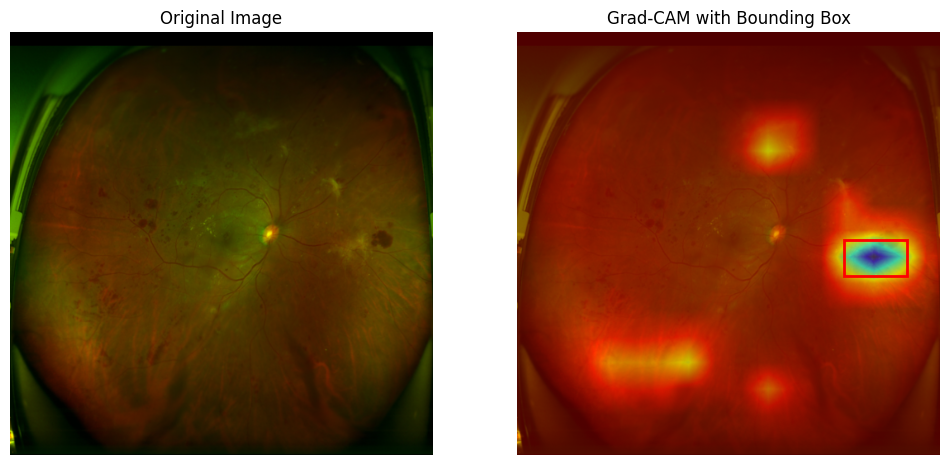

In [10]:
import torch.nn.functional as F
import matplotlib.patches as patches

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
        
    def __call__(self, x, class_idx=None):
        out_lesions, out_grades, _, _ = self.model(x)
        
        # Use lesion logits for GradCAM
        if class_idx is None:
            class_idx = out_lesions.argmax(dim=1).item()
            
        self.model.zero_grad()
        score = out_lesions[0, class_idx]
        score.backward(retain_graph=True)
        
        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]
        
        weights = np.mean(gradients, axis=(1, 2)) # Global Average Pooling of gradients
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        cam = np.maximum(cam, 0) # ReLU
        cam = cv2.resize(cam, (512, 512))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam

def plot_gradcam_bbox(image_tensor, cam, original_img):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    ax[0].imshow(original_img)
    ax[0].set_title('Original Image')
    ax[0].axis('off')
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    cam_img = heatmap + np.float32(original_img) / 255
    cam_img = cam_img / np.max(cam_img)
    
    ax[1].imshow(cam_img)
    ax[1].set_title('Grad-CAM with Bounding Box')
    ax[1].axis('off')
    
    # Threshold heatmap to find bounding boxes
    thresh = cv2.threshold(np.uint8(255 * cam), 127, 255, cv2.THRESH_BINARY)[1]
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        # Filter out very small boxes
        if w > 20 and h > 20:
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax[1].add_patch(rect)
            
    plt.show()

# Testing GradCAM on a verified rare-lesion validation sample
rare_cases = val_df[val_df['lesion'].apply(lambda x: sum([float(i.strip()) for i in str(x).strip('[]').split(',')][4:]) > 0)]
if not rare_cases.empty:
    sample_row = rare_cases.iloc[0]
    sample_img_path = os.path.join(DATA_DIR, 'MMRDR-UWF', sample_row['image'])
    if os.path.exists(sample_img_path):
        img_pil = Image.open(sample_img_path).convert('RGB').resize((512, 512))
        img_tensor = val_transform(img_pil).unsqueeze(0).to(device)
        
        # Register hook on the deepest spatial layer
        base_model = model.module if isinstance(model, nn.DataParallel) else model
        # Register hook on the deepest spatial layer
        grad_cam = GradCAM(model, base_model.layer4[-1])
        
        # Target rare lesion index 4 (NV)
        cam = grad_cam(img_tensor, class_idx=4)
        plot_gradcam_bbox(img_tensor, cam, img_pil)
